In [1]:
import pandas as pd

In [2]:
# Admission data
admissions = pd.read_csv('ADMISSIONS.csv.gz', compression='gzip')

# Patient specific info such as gender
patients = pd.read_csv('PATIENTS.csv.gz', compression='gzip')

In [3]:
patients['DOB'] = pd.to_datetime(patients['DOB'])

patients = patients[['SUBJECT_ID', 'DOB']]
patients.head()

,SUBJECT_ID,DOB
0,249,2075-03-13
1,250,2164-12-27
2,251,2090-03-15
3,252,2078-03-06
4,253,2089-11-26


In [4]:
admission_df = admissions.merge(patients, how='inner', on='SUBJECT_ID')
admission_df.head()

,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA,DOB
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1,2131-05-07
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,NaN,NaN,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,1,2082-07-17
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NaN,NaN,BRAIN MASS,0,1,2082-07-17
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,NaN,NaN,INTERIOR MYOCARDIAL INFARCTION,0,1,2100-05-31
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1,2101-11-21


In [5]:
admission_df['ADMIT_DATE'] = pd.to_datetime(admission_df['ADMITTIME']).dt.date
admission_df['DOB'] = pd.to_datetime(admission_df['DOB']).dt.date
admission_df['age'] = admission_df.apply(lambda e: (e['ADMIT_DATE'] - e['DOB']).days/365, axis=1)

In [6]:
# remove records with age over 200 years
admission_df = admission_df[admission_df['age'] < 200]

In [7]:
selected_admissions_df = admission_df[['SUBJECT_ID', 'HADM_ID', 'DOB', 'age']]
selected_admissions_df.head()

,SUBJECT_ID,HADM_ID,DOB,age
0,22,165315,2131-05-07,64.969863
1,23,152223,2082-07-17,71.178082
2,23,124321,2082-07-17,75.304110
3,24,161859,2100-05-31,39.041096
4,25,129635,2101-11-21,58.989041


In [8]:
# change age as integer
selected_admissions_df['age'] = selected_admissions_df['age'].astype(int)

C:\Users\yherw\AppData\Local\Temp\ipykernel_22020\1509671689.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_admissions_df['age'] = selected_admissions_df['age'].astype(int)


In [9]:
selected_admissions_df.head()

,SUBJECT_ID,HADM_ID,DOB,age
0,22,165315,2131-05-07,64
1,23,152223,2082-07-17,71
2,23,124321,2082-07-17,75
3,24,161859,2100-05-31,39
4,25,129635,2101-11-21,58


In [10]:
selected_admissions_df.to_csv("admission_with_age.csv")

In [11]:
selected_admissions_df['age'].describe()

count    56360.000000
mean        53.080376
std         26.636962
min          0.000000
25%         42.000000
50%         60.000000
75%         74.000000
max         89.000000
Name: age, dtype: float64

In [12]:
# remove records with age=0
selected_admissions_df = selected_admissions_df[selected_admissions_df['age'] > 0]

In [13]:
selected_admissions_df.to_csv("admission_with_age_nb.csv")

In [14]:
noteevents_df = pd.read_csv('NOTEEVENTS.csv')
diagnoses_df = pd.read_csv('DIAGNOSES_ICD.csv')

C:\Users\yherw\AppData\Local\Temp\ipykernel_22020\1614474500.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  noteevents_df = pd.read_csv('NOTEEVENTS.csv')


In [15]:
# Extract notes for hypertension related diagnoses (following ICD9-codes: '4010', '4011', '4019', ...'40599')
arr_subject_id=[]
arr_hadm_id=[]
arr_icd9_code=[]
for row in range(0, len(diagnoses_df)):
  if(diagnoses_df.loc[row, 'ICD9_CODE'] in ['4010', '4011', '4019', '40200', '40201','40210', '40290', '40291','40300','40301','40310', '40311', '40400','40401','40402','40403', '40410','40411','40412','40413','40490','40491','40492','40493','40501', '40509','40511', '40519', '40591', '40599'] and diagnoses_df.loc[row, 'SEQ_NUM'] == 1.0):
    arr_subject_id.append(diagnoses_df.loc[row, 'SUBJECT_ID'])
    arr_hadm_id.append(diagnoses_df.loc[row, 'HADM_ID'])
    arr_icd9_code.append(diagnoses_df.loc[row, 'ICD9_CODE'])

In [16]:
icd9_patients_discharge_summary_df = pd.DataFrame(columns=['SUBJECT_ID', 'HADM_ID','CATEGORY', 'TEXT',"ICD_9_CODE"])
patients_dict = {"SUBJECT_ID":[],"HADM_ID":[],"CATEGORY":[],"TEXT":[],"ICD_9_CODE":[]}

In [17]:
for i in range(0, len(noteevents_df)):
  if((noteevents_df.loc[i, 'SUBJECT_ID'] in arr_subject_id) and (noteevents_df.loc[i, 'HADM_ID'] in arr_hadm_id)  and (noteevents_df.loc[i, 'CATEGORY'] == 'Discharge summary')):
    patients_dict["SUBJECT_ID"].append(noteevents_df.loc[i, 'SUBJECT_ID'])
    patients_dict["HADM_ID"].append(noteevents_df.loc[i, 'HADM_ID'])
    patients_dict["CATEGORY"].append(noteevents_df.loc[i, 'CATEGORY'])
    patients_dict["TEXT"].append(noteevents_df.loc[i, 'TEXT'])
    patients_dict["ICD_9_CODE"].append(diagnoses_df.loc[(diagnoses_df['SUBJECT_ID'] == noteevents_df.loc[i, 'SUBJECT_ID']) & (diagnoses_df['HADM_ID'] == noteevents_df.loc[i, 'HADM_ID']), 'ICD9_CODE'].values[0])

In [18]:
patients_df = pd.DataFrame(patients_dict)

In [19]:
# merge notes and admission to get DOB and age of the patient
selected_patients_df = pd.merge(patients_df,selected_admissions_df, left_on=['SUBJECT_ID', 'HADM_ID'], right_on=['SUBJECT_ID', 'HADM_ID'], how='inner')

In [20]:
selected_patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SUBJECT_ID  266 non-null    int64  
 1   HADM_ID     266 non-null    float64
 2   CATEGORY    266 non-null    object 
 3   TEXT        266 non-null    object 
 4   ICD_9_CODE  266 non-null    object 
 5   DOB         266 non-null    object 
 6   age         266 non-null    int32  
dtypes: float64(1), int32(1), int64(1), object(4)
memory usage: 13.6+ KB


In [21]:
selected_patients_df.to_csv("icd9_hadm_hypertension_discharge_summary_with_age.csv")

In [22]:
# sort record based on patient's id, age and admission
patients_sorted = selected_patients_df.sort_values(by=['SUBJECT_ID', 'age', 'HADM_ID'], ascending=False)
patients_sorted.head()

,SUBJECT_ID,HADM_ID,CATEGORY,TEXT,ICD_9_CODE,DOB,age
37,99650,199859.0,Discharge summary,Admission Date: [**2156-12-25**] ...,40491,2101-07-10,55
163,97842,155272.0,Discharge summary,Admission Date: [**2144-4-13**] ...,4010,2102-02-25,42
251,95546,151745.0,Discharge summary,Admission Date: [**2169-4-26**] ...,4019,2092-09-02,76
83,95495,134287.0,Discharge summary,Admission Date: [**2121-1-30**] ...,40200,2066-10-06,54
45,93956,149121.0,Discharge summary,Admission Date: [**2174-4-5**] D...,4019,2143-04-11,31


In [23]:
# only keep the latest admission per patient
patients_clean = patients_sorted.drop_duplicates(subset=['SUBJECT_ID'])

In [24]:
len(patients_clean)

176

In [25]:
begin_text = "Brief Hospital Course:"
end_text = 'Medications on Admission:'
bhc = []
for row in patients_clean.itertuples():
    text = row.TEXT
    a,b = text.find(begin_text), text.find(end_text)
    if a>0 and b>0:
        bhc.append(text[a+len(begin_text):b])
    else:
        bhc.append("No Data")

In [26]:
patients_clean['BHC'] = bhc

C:\Users\yherw\AppData\Local\Temp\ipykernel_22020\1234754795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients_clean['BHC'] = bhc


In [27]:
bhc_summary_df = patients_clean[['SUBJECT_ID', 'HADM_ID','ICD_9_CODE','age','BHC']]

In [28]:
hypertension_bhc_df = bhc_summary_df[bhc_summary_df['BHC'] != "No Data"]
len(hypertension_bhc_df)

151

In [29]:
hypertension_bhc_df.to_csv("icd9_hypertension_bhc_summary_with_age_clean.csv")

Text(0, 0.5, 'Frequency')

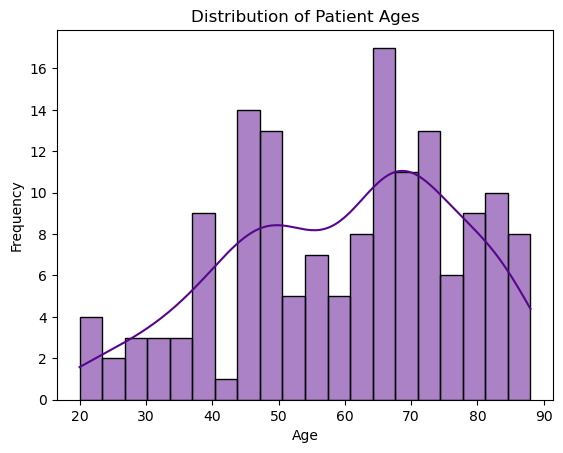

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=hypertension_bhc_df, x='age', bins=20, kde=True,color='#57068c')
plt.title("Distribution of Patient Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")

In [1]:
import scispacy
import en_ner_bc5cdr_md
nlp = en_ner_bc5cdr_md.load()

C:\ProgramData\anaconda3\Lib\site-packages\spacy\language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [2]:
import pandas as pd
hypertension_bhc_df = pd.read_csv("icd9_hypertension_bhc_summary_with_age_clean.csv")

In [3]:
sample = hypertension_bhc_df.loc[(hypertension_bhc_df['SUBJECT_ID'] == 26274)]
doc = nlp(sample.BHC.to_list()[0])

In [4]:
from spacy import displacy
colors = {'DISEASE': "#bf5700", "CHEMICAL": "#fe0000"}
options = {"ents": ['DISEASE', 'CHEMICAL'], "colors": colors}
displacy.render(doc, style="ent", jupyter=True, options=options)

In [5]:
result = []
adverse_events = ['dizziness', 'n/v', 'gerd', 'nausea', 'diarrhea', 'vomiting', 'headache', 'abdominal pain', 'constipation', 'dry cough']
for row in hypertension_bhc_df.itertuples():
    events = set()
    tokens= nlp(row.BHC).ents
    for i in range(0, len(tokens)):
        current_token = tokens[i].text.lower()
        if current_token in adverse_events:
            events.add(current_token)
    if events:
        trigger = f'{events} in {row.SUBJECT_ID}'
        print(trigger)
        result.append(list(events))

{'headache', 'nausea', 'abdominal pain', 'dizziness'} in 95546
{'diarrhea'} in 95495
{'headache'} in 93956
{'gerd'} in 93507
{'diarrhea', 'vomiting'} in 83031
{'n/v', 'headache'} in 82901
{'headache'} in 77553
{'n/v'} in 77037
{'nausea', 'vomiting'} in 75890
{'nausea', 'headache'} in 75525
{'headache'} in 75206
{'vomiting'} in 71129
{'diarrhea'} in 69250
{'nausea', 'vomiting'} in 64465
{'abdominal pain'} in 63961
{'constipation'} in 63917
{'headache'} in 63280
{'headache'} in 63190
{'headache'} in 59507
{'abdominal pain', 'headache'} in 59020
{'dizziness'} in 56527
{'headache'} in 54205
{'headache'} in 52605
{'nausea'} in 46423
{'nausea', 'diarrhea'} in 44491
{'nausea'} in 44191
{'nausea', 'headache'} in 30771
{'nausea'} in 30707
{'diarrhea', 'headache'} in 30548
{'nausea'} in 30183
{'abdominal pain'} in 29845
{'nausea', 'abdominal pain', 'constipation', 'headache'} in 29682
{'headache', 'dizziness'} in 29402
{'abdominal pain'} in 29346
{'dizziness', 'nausea', 'headache'} in 28944
{'na

In [6]:
len(result)

64

In [7]:
from collections import Counter
events_count = Counter()

for event in result:
    events_count.update(event)

In [8]:
print(events_count)

Counter({'headache': 27, 'nausea': 23, 'abdominal pain': 13, 'diarrhea': 9, 'vomiting': 7, 'n/v': 7, 'dizziness': 5, 'constipation': 5, 'gerd': 2})


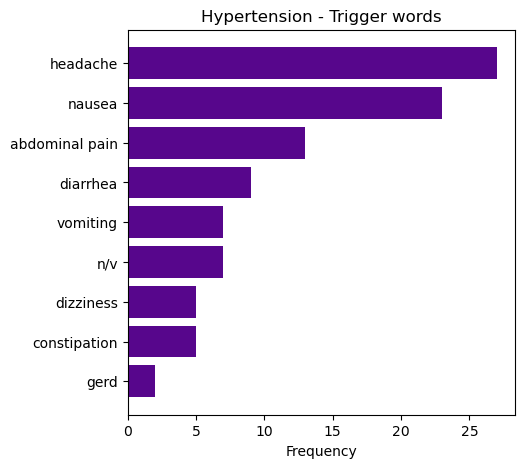

In [1]:
import matplotlib.pyplot as plt
labels = ['headache','nausea','abdominal pain', 'diarrhea', 'vomiting', 'n/v','dizziness', 'constipation', 'gerd']
values = [27, 23,13,9,7,7,5,5,2]
plt.figure(figsize=(5, 5))
plt.barh(labels, values, color='#57068c')
plt.xlabel('Frequency')
plt.title('Hypertension - Trigger words')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()